In [1]:
# Imports

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
	precision_score,
	recall_score,
    brier_score_loss,
	confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [2]:
def compute_metrics(df, threshold=0.7):

    y = df.y_true.values
    p = df.p_pred.values

    y_pred = (p > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y, p),
        "roc": roc_curve(y, p),

        "pr_auc": average_precision_score(y, p),
        "pr": precision_recall_curve(y, p),
        
        "f1": f1_score(y, y_pred),
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "brier": brier_score_loss(y, p),
        "confusion": {
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        },
        "n": len(df)
    }

In [3]:
def confusion_matrix_dataframe(cm):

    return pd.DataFrame(
        [
            [cm["TN"], cm["FP"]],
            [cm["FN"], cm["TP"]],
        ],
        index=["Actual Negative", "Actual Positive"],
        columns=["Predicted Negative", "Predicted Positive"]
    )

In [4]:
def metrics_for(experiment_id=None):
	if experiment_id:
		filename = f"results.{experiment_id}"
	else:
		filename = "results"

	results = json.load(open(f"./data/{filename}.json"))
	df = pd.DataFrame(results)

	metrics = {}

	metrics["overall"] = compute_metrics(df)

	for doc_type in df.doc_type.unique():
		metrics[doc_type] = compute_metrics(df[df.doc_type == doc_type])

	return metrics, df

# Inter-experiment analysis

In [5]:
compared_experiments = {
	"baseline_sentence_nli_r2": 
	{
		'label': 'Per-sentence NLI (baseline)',
		'segmentation': 'Sentences',
		'clustering': 'None'
	},
	"cluster_sentence_nli_r1": {
		'label': 'Sentence-level k-NN clustering',
		'segmentation': 'Sentences',
		'clustering': 'k-NN'
	},
	"cluster_sentence_nli_r2": {
		'label': 'Pair-wise sentence windows',
		'segmentation': 'Sentences',
		'clustering': 'NN'
	},
	"cluster_claims_nli_r1": {
		'label': 'Claims-level k-NN clustering',
		'segmentation': 'Claims',
		'clustering': 'k-NN'
	},
	"cluster_claims_nli_r2": {
		'label': 'Claims-level k-NN clustering (+temporal fix)',
		'segmentation': 'Claims',
		'clustering': 'k-NN'
	}
}

all_metrics = {}

# From conradoc paper (binary classification)
all_metrics['contradoc_llamav2'] = { 'overall': {
	'label': '\cite{li2024contradocunderstandingselfcontradictionsdocuments} (binary classification, LLaMAv2)',
	'segmentation': '-',
	'clustering': '-',
	'f1': 0.437,
	'accuracy': 0.505,
	'precision': 0.510,
	'recall': 0.383,
	'roc_auc': '-',
	'pr_auc': '-'
}}

for id, columns in compared_experiments.items():
	metrics, df = metrics_for(id)
	all_metrics[id] = metrics
	all_metrics[id]['overall'].update(columns)

all_metrics

<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
C:\Users\erwin\AppData\Local\Temp\ipykernel_11592\3253659535.py:34: SyntaxWarning: invalid escape sequence '\c'
  'label': '\cite{li2024contradocunderstandingselfcontradictionsdocuments} (binary classification, LLaMAv2)',


{'contradoc_llamav2': {'overall': {'label': '\\cite{li2024contradocunderstandingselfcontradictionsdocuments} (binary classification, LLaMAv2)',
   'segmentation': '-',
   'clustering': '-',
   'f1': 0.437,
   'accuracy': 0.505,
   'precision': 0.51,
   'recall': 0.383,
   'roc_auc': '-',
   'pr_auc': '-'}},
 'baseline_sentence_nli_r2': {'overall': {'roc_auc': 0.5526811718348467,
   'roc': (array([0.        , 0.        , 0.00226244, 0.00904977, 0.01357466,
           0.02488688, 0.02941176, 0.03167421, 0.03167421, 0.03393665,
           0.0361991 , 0.0361991 , 0.0361991 , 0.0361991 , 0.04072398,
           0.04298643, 0.04977376, 0.05429864, 0.05429864, 0.05429864,
           0.05429864, 0.05882353, 0.05882353, 0.06108597, 0.06108597,
           0.06561086, 0.0678733 , 0.07466063, 0.07466063, 0.07692308,
           0.07692308, 0.07918552, 0.08144796, 0.08144796, 0.08371041,
           0.08823529, 0.08823529, 0.09049774, 0.09276018, 0.09276018,
           0.09276018, 0.09728507, 0.099547

In [6]:
# Convert all_metrics to a dataframe with selected metrics per experiment

experiments = list(all_metrics.keys())
selected_metrics = ['label','segmentation','clustering', 'f1', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc']

data = {}
for exp in experiments:
	overall = all_metrics[exp]['overall']
	data[exp] = {metric: overall[metric] for metric in selected_metrics}

all_metrics_df = pd.DataFrame(data).T.set_index('label').rename(columns={
	'segmentation': 'Segmentation',
	'clustering': 'Clustering',
    'f1': 'F1 Score',
	'accuracy': 'Accuracy',
    'precision': 'Precision',
	'recall': 'Recall',
    'roc_auc': 'ROC AUC',
    'pr_auc': 'PR AUC',
})

all_metrics_df.index.name = "Experiment"
all_metrics_df

,Segmentation,Clustering,F1 Score,Accuracy,Precision,Recall,ROC AUC,PR AUC
Experiment,,,,,,,,
"\cite{li2024contradocunderstandingselfcontradictionsdocuments} (binary classification, LLaMAv2)",-,-,0.437,0.505,0.51,0.383,-,-
Per-sentence NLI (baseline),Sentences,None,0.365854,0.533109,0.57971,0.267261,0.552681,0.555306
Sentence-level k-NN clustering,Sentences,k-NN,0.649454,0.603371,0.586022,0.728285,0.64289,0.644874
Pair-wise sentence windows,Sentences,NN,0.649225,0.593258,0.574614,0.746102,0.669649,0.682918
Claims-level k-NN clustering,Claims,k-NN,0.634378,0.540024,0.531002,0.787736,0.574532,0.563332
Claims-level k-NN clustering (+temporal fix),Claims,k-NN,0.575983,0.547619,0.546371,0.608989,0.577631,0.571617


In [7]:

# For each column, find the maximum value (ignoring non-numeric like '-')
bold_values = {}
for col in all_metrics_df.columns:
	if col != 'label':  # Skip the index column
		numeric_values = pd.to_numeric(all_metrics_df[col], errors='coerce')
		if not numeric_values.isna().all():
			max_val = numeric_values.max()
			bold_values[col] = max_val

# Generate LaTeX table
latex = all_metrics_df.to_latex(
	float_format="%.3f",
	caption="Contradiction detection performance",
	label="tab:all_results",
)

latex = latex.replace('{table}', '{table*}')

# Post-process to bold the highest values
for col, max_val in bold_values.items():
	# Find the formatted max value in the LaTeX string
	formatted_max = f"{max_val:.3f}"
	# Replace with \textbf{formatted_max}
	latex = latex.replace(formatted_max, f"\\textbf{{{formatted_max}}}")

output_folder = f"data/combined/"
if not os.path.isdir(output_folder):
	os.makedirs(output_folder)
      
with open(f"{output_folder}/results.tex", "w") as f:
    f.write(latex)

print(latex)

\begin{table*}
\caption{Contradiction detection performance}
\label{tab:all_results}
\begin{tabular}{lllllllll}
\toprule
 & Segmentation & Clustering & F1 Score & Accuracy & Precision & Recall & ROC AUC & PR AUC \\
Experiment &  &  &  &  &  &  &  &  \\
\midrule
\cite{li2024contradocunderstandingselfcontradictionsdocuments} (binary classification, LLaMAv2) & - & - & 0.437 & 0.505 & 0.510 & 0.383 & - & - \\
Per-sentence NLI (baseline) & Sentences & None & 0.366 & 0.533 & 0.580 & 0.267 & 0.553 & 0.555 \\
Sentence-level k-NN clustering & Sentences & k-NN & \textbf{0.649} & \textbf{0.603} & \textbf{0.586} & 0.728 & 0.643 & 0.645 \\
Pair-wise sentence windows & Sentences & NN & \textbf{0.649} & 0.593 & 0.575 & 0.746 & \textbf{0.670} & \textbf{0.683} \\
Claims-level k-NN clustering & Claims & k-NN & 0.634 & 0.540 & 0.531 & \textbf{0.788} & 0.575 & 0.563 \\
Claims-level k-NN clustering (+temporal fix) & Claims & k-NN & 0.576 & 0.548 & 0.546 & 0.609 & 0.578 & 0.572 \\
\bottomrule
\end{tabular}


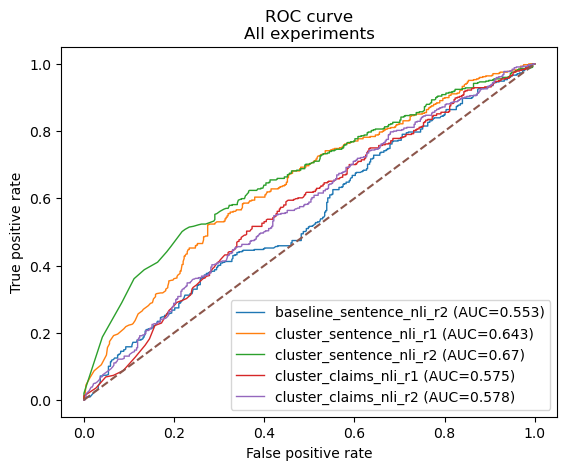

In [8]:
# ROC curve


plt.figure()

for id, metrics in all_metrics.items():
	if not 'roc' in metrics['overall']:
		continue

	fpr, tpr, _ = metrics["overall"]["roc"]
	plt.plot(fpr, tpr, label=f"{id} (AUC={metrics['overall']['roc_auc']:.3})", linewidth=1)

plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve\nAll experiments")
plt.legend()

plt.savefig(f"{output_folder}/roc.jpg")

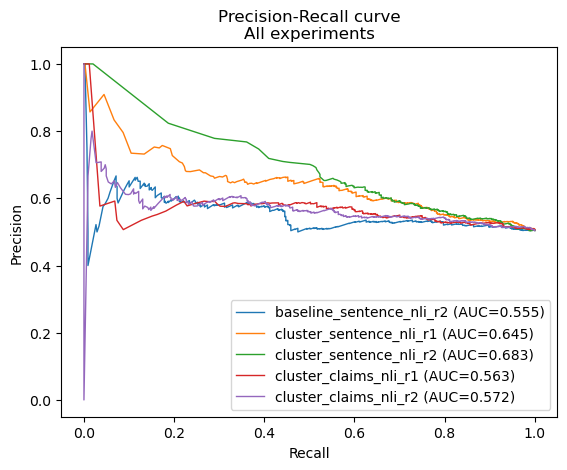

In [9]:
# Precision-Recall curve

plt.figure()

for id, metrics in all_metrics.items():
	if not 'pr' in metrics['overall']:
		continue

	prec, rec, _ = metrics['overall']['pr']
	plt.plot(rec, prec, label=f"{id} (AUC={metrics['overall']['pr_auc']:.3})", linewidth=1)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve\nAll experiments")
plt.legend()

plt.savefig(f"{output_folder}/pr.jpg")

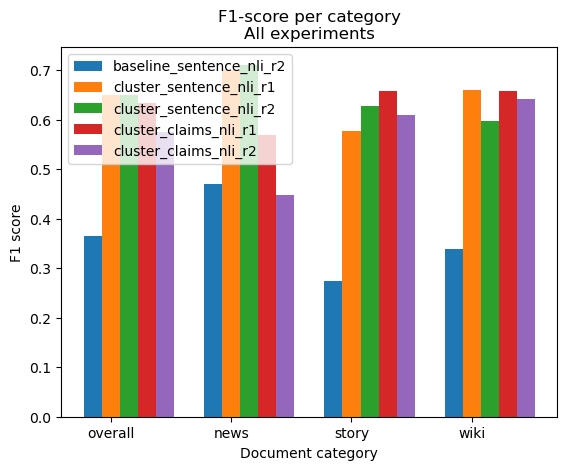

In [10]:
# F1 per category graph

cats = all_metrics['baseline_sentence_nli_r2'].keys()
x = np.arange(len(cats))  # the label locations

plt.figure()

width = 0.15  # the width of the bars
multiplier = 0

for id, metrics in all_metrics.items():
	if id == 'contradoc_llamav2':
		continue

	offset = width * multiplier
	cats = list(metrics.keys())
	plot_y = [ metrics[cat]['f1'] for cat in cats]

	plt.bar(x + offset, plot_y, width, label=id)
	multiplier += 1

plt.ylabel("F1 score")
plt.xlabel("Document category")
plt.xticks(x + width, cats)
plt.title(f"F1-score per category\nAll experiments")
plt.legend()

plt.savefig(f"{output_folder}/categories.jpg")

# Individual experiments

In [11]:
# Load metrics

#experiment_id = "baseline_sentence_nli_r1"
#experiment_id = "baseline_sentence_nli_r2"
#experiment_id = "cluster_sentence_nli_r1"
experiment_id = "cluster_sentence_nli_r2"
#experiment_id = "cluster_sentence_nli_r3"
#experiment_id = "cluster_claims_nli_r1"
#experiment_id = "cluster_claims_nli_r2"
#experiment_id = "cluster_claims_nli_r3"
#experiment_id = "cluster_claims_nli_r4"
#experiment_id = "window_sentence_nli_r1"

metrics, df = metrics_for(experiment_id)

In [12]:
output_folder = f"data/{experiment_id}/"
if not os.path.isdir(output_folder):
	os.makedirs(output_folder)

In [13]:
# Results overview table

table = pd.DataFrame(metrics).T

table.drop(columns=['confusion', 'roc', 'pr'], inplace=True)

table = table.astype({ 'n': int })

latex = table.to_latex(
    float_format="%.3f",
    caption="Contradiction detection performance",
    label="tab:results",

)

with open(f"{output_folder}/results.tex", "w") as f:
    f.write(latex)

print(latex)

table

\begin{table}
\caption{Contradiction detection performance}
\label{tab:results}
\begin{tabular}{llllllllr}
\toprule
 & roc_auc & pr_auc & f1 & accuracy & precision & recall & brier & n \\
\midrule
overall & 0.670 & 0.683 & 0.649 & 0.593 & 0.575 & 0.746 & 0.358 & 890 \\
wiki & 0.770 & 0.773 & 0.711 & 0.631 & 0.590 & 0.893 & 0.334 & 295 \\
story & 0.588 & 0.594 & 0.627 & 0.535 & 0.521 & 0.787 & 0.419 & 284 \\
news & 0.674 & 0.715 & 0.598 & 0.611 & 0.629 & 0.570 & 0.326 & 311 \\
\bottomrule
\end{tabular}
\end{table}



,roc_auc,pr_auc,f1,accuracy,precision,recall,brier,n
overall,0.669649,0.682918,0.649225,0.593258,0.574614,0.746102,0.358343,890
wiki,0.769954,0.772581,0.710875,0.630508,0.590308,0.893333,0.33351,295
story,0.58776,0.593984,0.627119,0.535211,0.521127,0.787234,0.419283,284
news,0.674278,0.715016,0.598007,0.610932,0.629371,0.56962,0.326249,311


In [14]:
# Confusion matrix table per doc type

for doc_type in metrics.keys():
    cm_df = confusion_matrix_dataframe(metrics[doc_type]['confusion'])
    latex = cm_df.to_latex(
        caption=f"Confusion matrix for contradiction detection ({doc_type})",
        label="tab:confusion_matrix"
    )

    with open(f"{output_folder}/cm_{doc_type}.tex", "w") as f:
        f.write(latex)

    print(latex)
    print()

\begin{table}
\caption{Confusion matrix for contradiction detection (overall)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 193 & 248 \\
Actual Positive & 114 & 335 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (wiki)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 52 & 93 \\
Actual Positive & 16 & 134 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (story)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 41 & 102 \\
Actual Positive & 30 & 111 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (news)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}

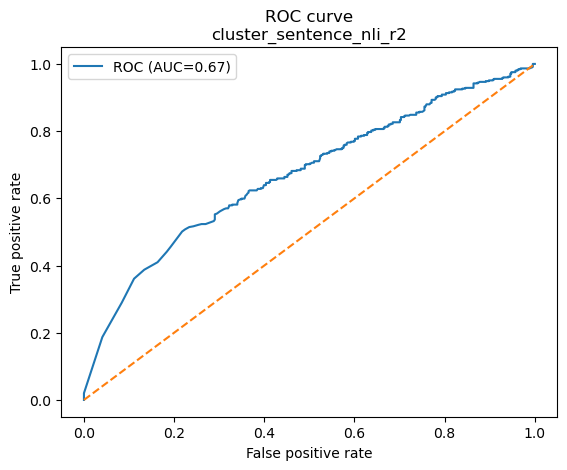

In [15]:
# ROC curve

fpr, tpr, _ = metrics["overall"]["roc"]

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={metrics['overall']['roc_auc']:.3})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve\n{experiment_id}")
plt.legend()

plt.savefig(f"{output_folder}/roc.jpg")

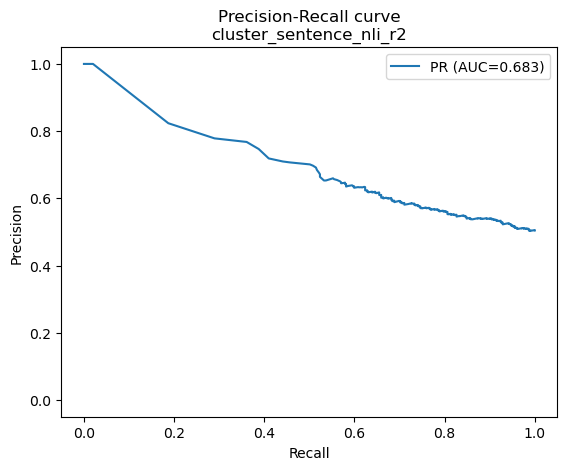

In [16]:
# Precision-Recall curve

prec, rec, _ = metrics['overall']['pr']

plt.figure()
plt.plot(rec, prec, label=f"PR (AUC={metrics['overall']['pr_auc']:.3})")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve\n{experiment_id}")
plt.legend()

plt.savefig(f"{output_folder}/pr.jpg")

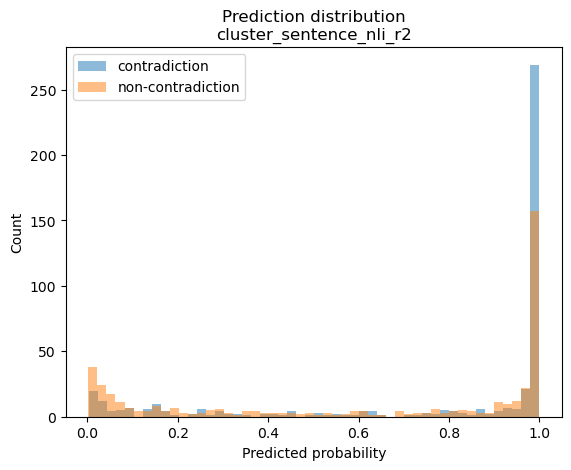

In [17]:
# Prediction distribution histogram

plt.figure()

plt.hist(df[df.y_true==1].p_pred, bins=50, alpha=0.5, label="contradiction")
plt.hist(df[df.y_true==0].p_pred, bins=50, alpha=0.5, label="non-contradiction")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title(f"Prediction distribution\n{experiment_id}")
plt.legend()

plt.savefig(f"{output_folder}/histogram.jpg")

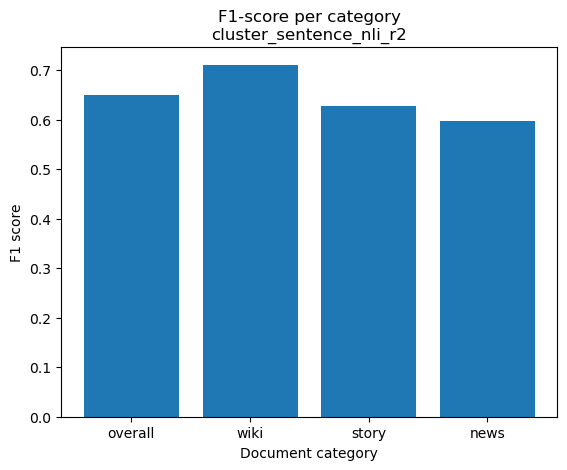

In [18]:
# F1 per category graph

cats = list(metrics.keys())
f1_scores = [metrics[c]["f1"] for c in cats]

plt.figure()
plt.bar(cats, f1_scores)
plt.ylabel("F1 score")
plt.xlabel("Document category")
plt.title(f"F1-score per category\n{experiment_id}")

plt.savefig(f"{output_folder}/categories.jpg")

# Analysis: per contra_type

In [ ]:
# Load data and prepare One-vs-Clean labels

RESULTS_FILE = "./data/results.cluster_sentence_nli_r2.json"
CONTRADOC_FILE = "./datasets/ContraDoc/ContraDoc.json"
EXPERIMENT_ID = "cluster_sentence_nli_r2"
OUTPUT_DIR = f"./data/{EXPERIMENT_ID}"
THRESHOLD = 0.7

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load model output
results_df = pd.DataFrame(json.load(open(RESULTS_FILE)))

# Load ContraDoc and map unique_id -> contra_type.
contradoc = json.load(open(CONTRADOC_FILE))
contra_rows = []
for split in ["pos", "neg"]:
    for _, item in contradoc.get(split, {}).items():
        uid = item.get("unique id")
        ctype = item.get("contra_type", [])
        if uid is not None:
            contra_rows.append({"unique_id": uid, "contra_type": ctype})

contra_df = pd.DataFrame(contra_rows).drop_duplicates(subset=["unique_id"])
merged = results_df.merge(contra_df, on="unique_id", how="left")
merged["contra_type"] = merged["contra_type"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Clean = non-contradiction
clean_mask = (merged["y_true"] == 0) & (merged["contra_type"].apply(len) == 0)
if clean_mask.sum() == 0:
    clean_mask = merged["y_true"] == 0

all_types = sorted({t for types in merged["contra_type"] for t in types})
print(f"Number of contra_types: {len(all_types)}")
print(f"Number of clean samples: {int(clean_mask.sum())}")
print(f"Saving plots to: {OUTPUT_DIR}")

Number of contra_types: 9
Number of clean samples: 441
Saving plots to: ./data/cluster_sentence_nli_r2


In [27]:
# Metrics per contra_type (One-vs-Clean)

rows = []
pr_curves_by_type = {}

for ctype in all_types:
    pos_mask = merged["contra_type"].apply(lambda types: ctype in types)
    eval_df = merged[pos_mask | clean_mask].copy()

    y_bin = pos_mask[pos_mask | clean_mask].astype(int).values
    p = eval_df["p_pred"].values
    y_pred = (p > THRESHOLD).astype(int)

    if len(np.unique(y_bin)) < 2:
        continue

    pr_auc = average_precision_score(y_bin, p)
    precision, recall, _ = precision_recall_curve(y_bin, p)

    pr_curves_by_type[ctype] = {
        "precision": precision,
        "recall": recall,
        "pr_auc": pr_auc,
        "n_positive": int(y_bin.sum()),
        "n_clean": int((y_bin == 0).sum())
    }

    rows.append({
        "contra_type": ctype,
        "f1": f1_score(y_bin, y_pred, zero_division=0),
        "pr_auc": pr_auc,
        "n_positive": int(y_bin.sum()),
        "n_clean": int((y_bin == 0).sum())
    })

metrics_by_type = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
metrics_by_type

,contra_type,f1,pr_auc,n_positive,n_clean
0,Content,0.570667,0.585956,288,441
1,Negation,0.353808,0.457082,87,441
2,Numeric,0.270718,0.378563,65,441
3,Emotion/Mood/Feeling,0.321608,0.282892,86,441
4,Perspective/View/Opinion,0.305825,0.246439,101,441
5,Factual,0.218289,0.222802,54,441
6,Relation,0.130137,0.125270,25,441
7,Causal,0.179487,0.106516,36,441
8,Other,0.008000,0.005000,1,441


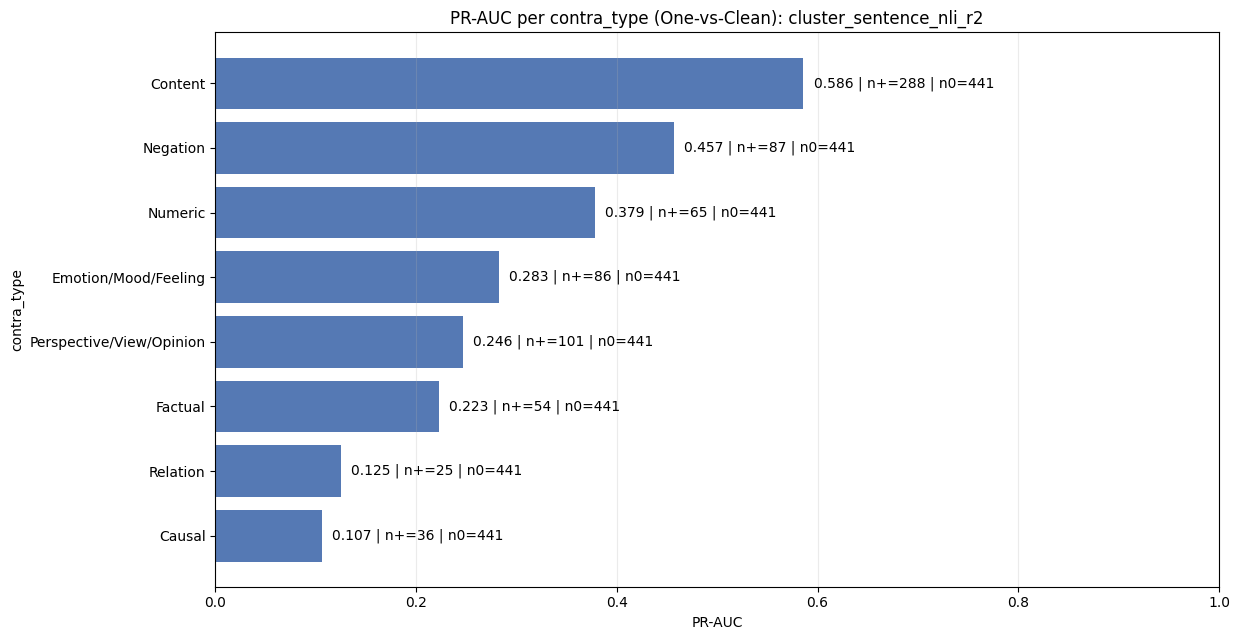

In [28]:
# PR-AUC chart per contra_type (without Other)

plot_df = metrics_by_type[metrics_by_type["contra_type"].str.lower() != "other"]
plot_df = plot_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12.5, 6.5))
plt.barh(plot_df["contra_type"], plot_df["pr_auc"], color="#4C72B0", alpha=0.95)
plt.gca().invert_yaxis()
plt.xlim(0, 1)
plt.xlabel("PR-AUC")
plt.ylabel("contra_type")
plt.title(f"PR-AUC per contra_type (One-vs-Clean): {EXPERIMENT_ID}")
plt.grid(axis="x", alpha=0.25)

for i, row in plot_df.iterrows():
    value = row["pr_auc"]
    label = f"{value:.3f} | n+={int(row['n_positive'])} | n0={int(row['n_clean'])}"
    x = min(value + 0.01, 0.98)
    plt.text(x, i, label, va="center", ha="left", fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_auc_{EXPERIMENT_ID}_one_vs_clean_by_contra_type.png", dpi=300)
plt.show()

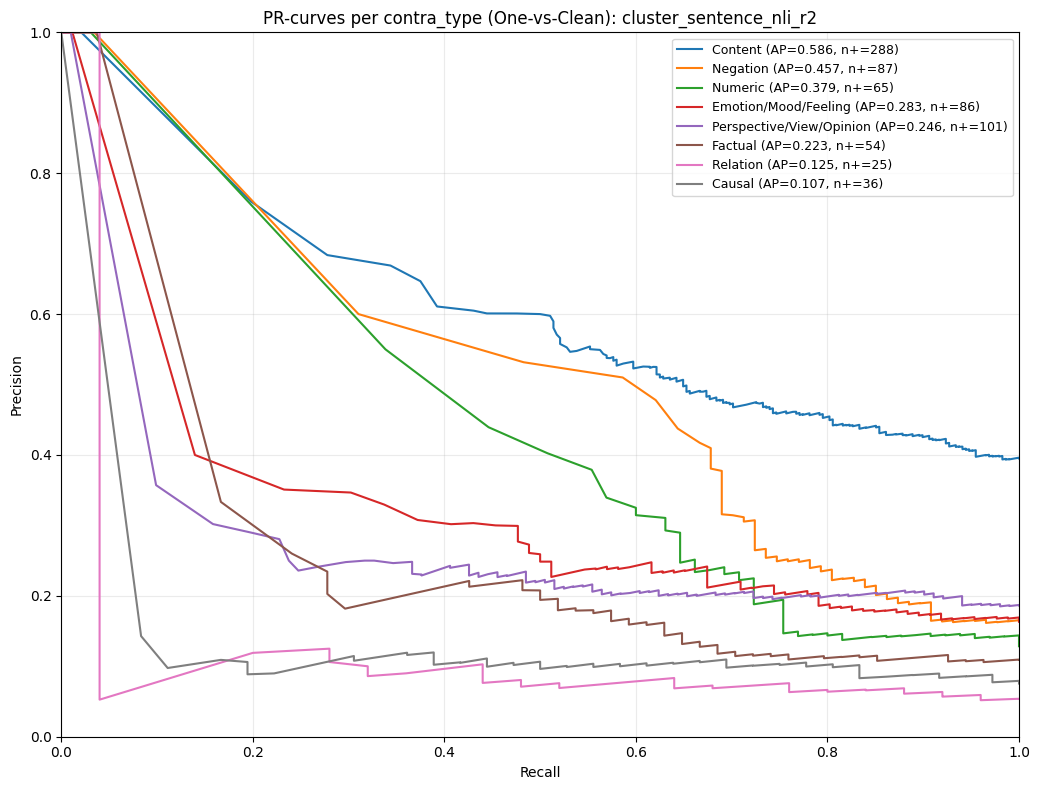

In [29]:
# PR curves per contra_type (without Other)

plot_df = metrics_by_type[metrics_by_type["contra_type"].str.lower() != "other"]
plot_df = plot_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10.5, 8))
for _, row in plot_df.iterrows():
    ctype = row["contra_type"]
    curve = pr_curves_by_type[ctype]
    plt.plot(
        curve["recall"],
        curve["precision"],
        label=f"{ctype} (AP={curve['pr_auc']:.3f}, n+={curve['n_positive']})"
    )

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR-curves per contra_type (One-vs-Clean): {EXPERIMENT_ID}")
plt.grid(alpha=0.25)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_curves_{EXPERIMENT_ID}_one_vs_clean_by_contra_type.png", dpi=300)
plt.show()